# Thermal Pulse Propagation

Marlim3 - Python Tutorials


In this tutorial, we will explore how to set up and run a transient simulation in the Marlim3 multiphase flow simulator.

Our goal is to simulate the injection of a hot fluid, through a thermal pulse, into a pipeline that is initially at 20 °C, but exposed to a cold subsea environment at 4 °C. More than just applying an insulation layer and checking the result, we want to study in detail how this heat wave propagates over time and along the length of the pipeline.

In the subsea environment, if the fluid loses too much heat to the sea and its temperature drops below critical limits, components of the mixture may crystallize. This results in the formation of solid hydrate plugs or significant wax deposition, clogging the line and interrupting production.

To demonstrate the importance of managing this energy loss, we will run our thermal propagation scenario twice:

- **With a bare steel pipeline (no insulation)**: to observe the rapid dissipation of the heat wave along the line.

- **With the addition of a thermal insulation layer of polyethylene foam**: to evaluate the heat-retention capacity and the preservation of the pulse.

In the end, we will graphically compare the temporal evolution at different monitoring points along the line, providing a visual demonstration of how insulation dictates the feasibility and safety of the flow.

In [1]:
import marlim3
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## 1. Global Settings and Boundary Conditions

The first step is to instantiate the case study and define the general settings.  

In [ ]:
# Initializes the main Marlim3 object
case = marlim3.Branch()

# Initial settings
case.initialConfig = {
    "transient": True,
    "initialCondition": 0,
    "initialFluidId": 0
}

# Simulation time control
case.time = {
    "finalTime": 3000.0,
    "times": [0.0],
    "maxDT": [0.4]
}

# Production fluid definition (35.95 API Oil, no free gas or initial water)
case.productionFluid = [{
    "id": 0,
    "api": 35.95,
    "gor": 0.0,
    "gasDensity": 0.845,
    "bsw": 0.0
}]

# Outlet boundary condition
case.separator = {
    "time": [0],
    "pressure": [15.0]
}

# Inlet boundary condition
# We simulate a thermal pulse: fluid enters at 20°C, rises to 80°C between 1000s and 1500s, then returns to 20°C.
case.liquidSource = [{
    "id": 0,
    "prodFluidId": 0,
    "measuredLength": 0.0,
    "time": [0, 999, 1000, 1499, 1500, 3000],
    "temperature": [20.0, 20.0, 80.0, 80.0, 20.0, 20.0],
    "liquidFlowRate": [3000, 3000, 3000, 3000, 3000, 3000]
}]


## 2. Configuring Data Acquisition (Sensors)

To monitor the heat wave propagating through the pipeline, we will place sensors (point trends) every 100 meters along the line.

In [3]:
# Defines positions from 0m to 1000m
monitored_sections = [100 * i for i in range(0, 11)]

case.productionTrend = [{"active": True,
                         "measuredLength": pos,
                         "dt": 1.0,
                         "label": f"PIPE-1_Sec_{int(pos)}m",
                         "temperature": True,
                         "externalHeatCoef": True
                         } for pos in monitored_sections]

## 3. Materials and Cross-Sections

In this step, we define the thermophysical properties of the materials involved. Thermal conductivity and heat capacity dictate how the pipe wall stores and loses heat to the environment.

We will create two different cross-sections so that we can switch between them during the comparative study.

In [4]:
# Material registration in the model database
case.material = [{"id": 0,
                  "label": "Carbon Steel",
                  "type": 0,
                  "conductivity": 45.0,
                  "specificHeat": 470.0,
                  "rho": 7850.0},

                 {"id": 1,
                  "label": "Poly_Ethylene_Foam",
                  "type": 0,
                  "conductivity": 0.04,
                  "specificHeat": 2300.0,
                  "rho": 32.0}
                ]

# Section 1: Pipe with carbon steel only
section_no_insulation = {"id": 0,
                         "label": "Section_No_Insulation",
                         "innerDiameter": 0.1524,
                         "roughness": 5e-05,
                         "layers": [{"label": "Tube Wall - Steel",
                                     "materialId": 0,
                                     "layerMeasurementType": "THICKNESS",
                                     "thickness": 0.0071,
                                     "discretization": 3}]
                         }

# Section 2: Carbon steel pipe coated with 25mm of Polyethylene Foam
section_with_insulation = {"id": 1,
                           "label": "Section_With_PE_Insulation",
                           "innerDiameter": 0.1524,
                           "roughness": 5e-05,
                           "layers": [{"label": "Tube Wall - Steel",
                                       "materialId": 0,
                                       "layerMeasurementType": "THICKNESS",
                                       "thickness": 0.0071,
                                       "discretization": 3},

                                      {"label": "Insulation - Foam",
                                       "materialId": 1,
                                       "layerMeasurementType": "THICKNESS",
                                       "thickness": 0.025,
                                       "discretization": 10}]
                           }

# Assigns both options to the model
case.crossSection = [section_no_insulation, section_with_insulation]


## 4. Comparative Simulation

Here we set up the pipeline topology and the initial thermo‑fluid‑dynamic state. The script runs Marlim3 for each coating configuration and stores the outputs.

In [5]:
# Base pipe configuration
case.productionPipe = [{"id": 0,
                        "label": "PIPE-1",
                        "crossSectionId": 0,          # This ID will be dynamically changed in the loop
                        "angle": 0.0,
                        "environment": 0,
                        "discretization": [{"numCells": 100, "length": 5.0}],
                        "initialConditions": {
                            "measuredPosition": [0, 1],
                            "temp": [20.0, 20.0],
                            "pressure": [15.0, 15.0],
                            "holdup": [1.0, 1.0],
                            "complementaryFluidFraction": [0.0, 0.0],
                            "usl": [1.9, 1.9],
                            "usg": [0.0, 0.0],
                            "ambientTemp": [4.0, 4.0],
                            "ambientVel": [0.3, 0.3],
                            "ambientConductivity": [0.6, 0.6],
                            "ambientSpecificHeat": [3990.0, 3990.0],
                            "ambientDensity": [1025.0, 1025.0],
                            "ambientVisc": [1.5, 1.5]}
                       }]

# Defining scenarios for the loop
study_cases = [
    {"name": "no_insulation",   "cross_section_id": 0, "title": "Bare Steel (No Insulation)"},
    {"name": "with_insulation", "cross_section_id": 1, "title": "With Polyethylene Foam"}
]

default_folder = "marlim3_resultados"

for c in study_cases:

    # 1. Changes which cross-section the pipe will use
    case.productionPipe[0]["crossSectionId"] = c["cross_section_id"]

    # 2. Runs the simulation
    case.simulate()

    # 3. Renames the output folder
    destination_folder = f"results_{c['name']}"
    if os.path.exists(destination_folder):
        shutil.rmtree(destination_folder)
    os.rename(default_folder, destination_folder)

------------------------------------------   Eventos no Tramo -------------------------------------------
0  momento = 999 segundos  tipo de evento = Aumentando temperatura de Liquido, Fonte
1  momento = 1499 segundos  tipo de evento = Diminuindo temperatura de Liquido, Fonte
2  momento = 1e+09 segundos  tipo de evento = Evento buffer
0 % da simulacao alcancado
5.00267 % da simulacao alcancado
10.0053 % da simulacao alcancado
14.9973 % da simulacao alcancado
20 % da simulacao alcancado
25.0027 % da simulacao alcancado
29.9947 % da simulacao alcancado
34.9973 % da simulacao alcancado
40 % da simulacao alcancado
45.0027 % da simulacao alcancado
50.0053 % da simulacao alcancado
54.9973 % da simulacao alcancado
60 % da simulacao alcancado
65.0027 % da simulacao alcancado
70.0053 % da simulacao alcancado
74.9973 % da simulacao alcancado
80 % da simulacao alcancado
85.0027 % da simulacao alcancado
89.9947 % da simulacao alcancado
94.9973 % da simulacao alcancado
99.9893 % da simulacao alcanc

## 5. Post-Processing and Results Visualization

Finally, we use `pandas` and `matplotlib` to read the binary/CSV data generated by Marlim3 and visualize the impact of insulation. We will plot the point trends of the first three sensors along the pipeline.

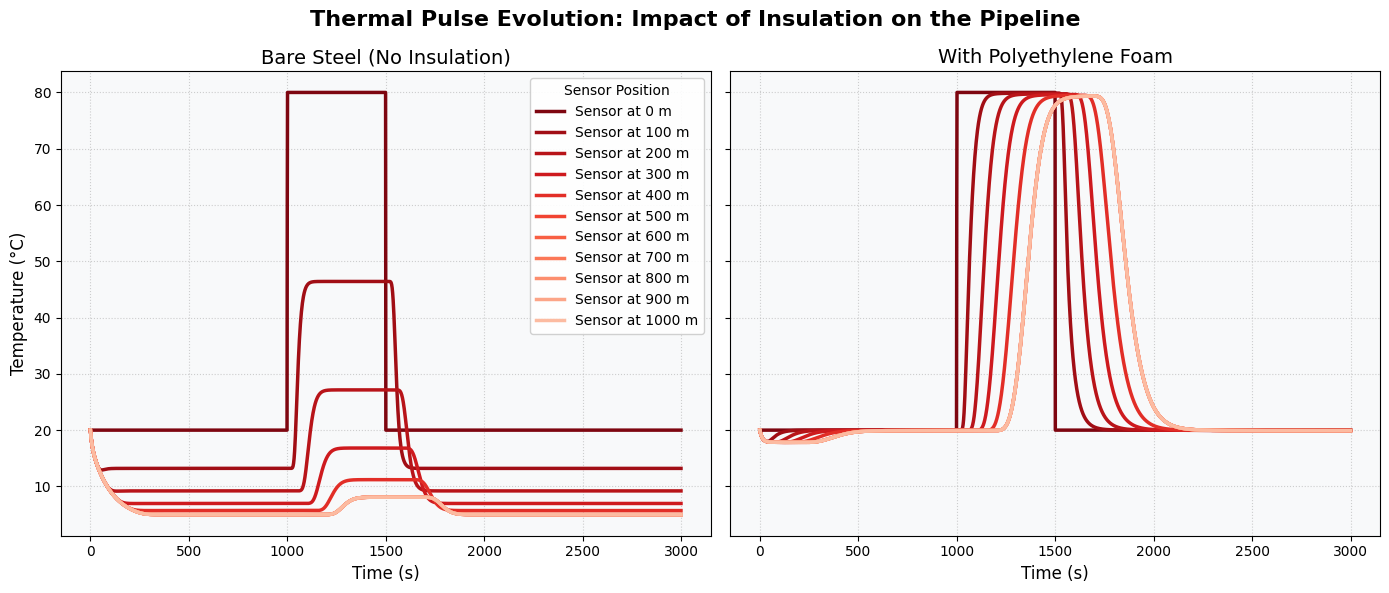

In [6]:
# ── Color palette ──────────────────────────────────────────────────────────────
n = len(monitored_sections)
colors = [cm.Reds(0.95 - 0.70 * i / (n - 1)) for i in range(n)]

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

fig.suptitle(
    "Thermal Pulse Evolution: Impact of Insulation on the Pipeline",
    fontsize=16,
    fontweight='bold'
)

# ── Plot loop ──────────────────────────────────────────────────────────────────
for idx, c in enumerate(study_cases):
    ax = axs[idx]
    results_folder = f"results_{c['name']}"

    for i, pos in enumerate(monitored_sections):
        path = os.path.join(results_folder, f"TENDP-{pos}.dat")
        if os.path.exists(path):
            df = pd.read_csv(path, sep=';', skiprows=3)
            ax.plot(
                df[' Time (s) '],
                df[' Temperature (C) '],
                label=f'Sensor at {pos} m',
                lw=2.5,
                color=colors[i % len(colors)]
            )

    # ── Subplot formatting ─────────────────────────────────────────────────────
    ax.set_title(c["title"], fontsize=14)
    ax.set_xlabel("Time (s)", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_facecolor('#F8F9FA')

    if idx == 0:
        ax.set_ylabel("Temperature (°C)", fontsize=12)
        ax.legend(
            title="Sensor Position",
            loc='upper right',
            framealpha=0.9,
            edgecolor='#CCCCCC'
        )

# ── Final adjustments ─────────────────────────────────────────────────────────
plt.tight_layout()
plt.show()

## 6. Conclusion

By analyzing the plots side by side, one can clearly see the physical impact of the thermal coating on the fluid behavior. The propagation of the heat wave directly follows the radial thermal resistance of the pipe wall.

**Bare Carbon Steel Pipe without Insulation**

Carbon steel has a high thermal conductivity, close to 45 W/m·K. Since the resistance to heat transfer is very small, the thermal energy injected by the hot pulse is quickly dissipated to the subsea environment at 4 °C. In the first plot, the fluid temperature drops sharply within the first few tens of meters. In a real operation, this abrupt cooling would make the fluid quickly cross the hydrate formation curve or the wax crystallization temperature, resulting in severe line blockage.

**Pipe with Polyethylene Foam Insulation**

The addition of 25 mm of a material with low thermal conductivity of 0.04 W/m·K completely changes the flow profile. The foam acts as a physical barrier that drastically increases the overall thermal resistance. The heat pulse is preserved and can travel much longer distances before dissipating. In addition, the 20 °C line temperature is maintained along the entire length of the pipeline, which does not occur in the uninsulated case.

Correctly sizing the insulation prevents the fluid temperature from dropping below critical limits during its journey through the cold subsea environment. With this thermal retention, crystallization of mixture components and the consequent formation of hydrates or wax deposition are avoided, ensuring uninterrupted flow.